# N1 · 在真实 gpt2 找 induction head

> 配套 12.5-L2 · **小而真**: induction head 是 mech interp 最著名的 circuit (in-context learning 机制)。
> 喂「随机 token 重复两遍」, 逐头算 induction 分数, 在真 gpt2 找到它, 看注意力图, 并消融验证因果。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import circuits as ci
import realmodels as rm
import numpy as np, torch
print('真实模型:', rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


> 若 gpt2=False 则无 HF 缓存, 跳过 (本 notebook 全程真实 gpt2)。

## 1. 喂重复序列, 逐 (层,头) 算 induction 分数

序列: 49 token (BOS + 24 随机 token 重复两遍)


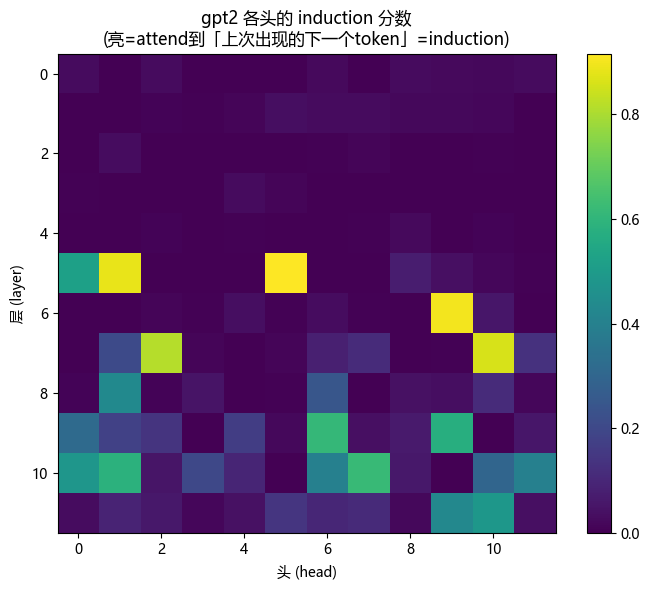

→ induction 分数最高: 层5 头5 (分数 0.92) = gpt2 的一个 induction head!


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
tok, model = rm.gpt2(output_attentions=True)
if model is not None:
    tokens, k = ci.make_repeated_tokens(tok, n_unique=24, seed=0)
    print(f'序列: {tokens.shape[1]} token (BOS + {k} 随机 token 重复两遍)')
    scores = ci.induction_scores(model, tokens, k)
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(scores, cmap='viridis', aspect='auto')
    ax.set_xlabel('头 (head)'); ax.set_ylabel('层 (layer)'); ax.set_title('gpt2 各头的 induction 分数\n(亮=attend到「上次出现的下一个token」=induction)')
    plt.colorbar(im); plt.tight_layout(); plt.show()
    best = np.unravel_index(np.argmax(scores), scores.shape)
    print(f'→ induction 分数最高: 层{best[0]} 头{best[1]} (分数 {scores[best]:.2f}) = gpt2 的一个 induction head!')
else:
    print('无 gpt2')

## 2. 看这个头的注意力图 (它真的 attend 到「上次的下一个」吗)

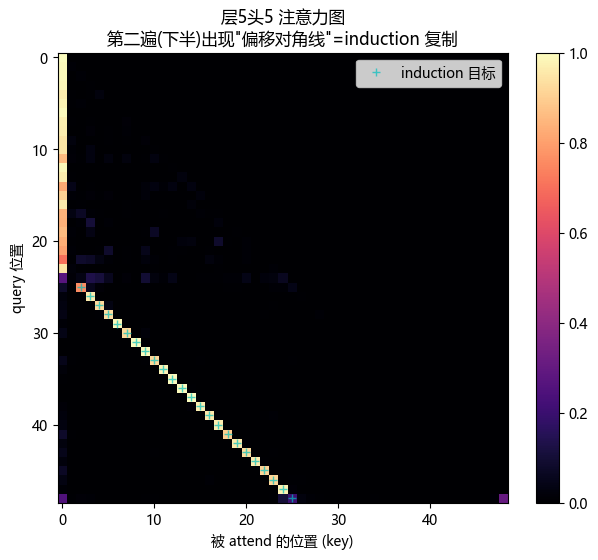

→ 第二遍每个位置的注意力落在「第一遍该token的下一个」(青十字) → induction 模式坐实。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
if model is not None:
    with torch.no_grad():
        out = model(tokens, output_attentions=True)
    a = out.attentions[best[0]][0, best[1]].numpy()   # (seq, seq) 该头的注意力
    fig, ax = plt.subplots(figsize=(6.5,5.5))
    im = ax.imshow(a, cmap='magma'); ax.set_xlabel('被 attend 的位置 (key)'); ax.set_ylabel('query 位置')
    ax.set_title(f'层{best[0]}头{best[1]} 注意力图\n第二遍(下半)出现"偏移对角线"=induction 复制')
    # 标出 induction 对角线 (第二遍 i → i-k+1)
    xs = [(i-k)+1 for i in range(1+k, tokens.shape[1])]; ys = list(range(1+k, tokens.shape[1]))
    ax.plot(xs, ys, 'c+', ms=6, alpha=0.7, label='induction 目标')
    ax.legend(); plt.colorbar(im); plt.tight_layout(); plt.show()
    print('→ 第二遍每个位置的注意力落在「第一遍该token的下一个」(青十字) → induction 模式坐实。')

## 3. 因果验证: 消融这个头, 预测重复变差吗

In [4]:
if model is not None:
    base = ci.induction_loss(model, tokens, k)
    abl = ci.induction_loss(model, tokens, k, ablate=tuple(best))
    print(f'induction loss (预测重复的交叉熵, 越低越好):')
    print(f'  完整模型:        {base:.3f}')
    print(f'  消融 层{best[0]}头{best[1]}: {abl:.3f}  ({"变差 ✓ 因果确认" if abl>base else "没变差"})')
    print(f'  损害: {abl-base:+.3f}')
    print('→ 消融 induction head 使"预测重复"变差 = 因果确认它负责 induction (M12.3 干预)。')
    print('  (损害可能不大, 因为 gpt2 有多个 induction head 冗余 — N2 会看到整组)')

induction loss (预测重复的交叉熵, 越低越好):
  完整模型:        1.021
  消融 层5头5: 1.076  (变差 ✓ 因果确认)
  损害: +0.054
→ 消融 induction head 使"预测重复"变差 = 因果确认它负责 induction (M12.3 干预)。
  (损害可能不大, 因为 gpt2 有多个 induction head 冗余 — N2 会看到整组)


## 4. 反思
你在**真实 gpt2** 上找到并验证了 induction head。带走:
- **induction head**: attend 到「上次出现的下一个 token」→ 复制 = in-context learning 机制 (L2)。
- **真实大模型的真实 circuit**: gpt2 预训练涌现, 你用注意力分数找到它、消融因果验证。
- **冗余**: 损害不大 = 有备份头 (L3); N2 看整组。
下一步 N2: 逐头贡献热图, 看 induction 是一组头协作。